In [21]:
from pathlib import Path
import sys
import time
import statistics
import platform

import torch
import pandas as pd
import matplotlib.pyplot as plt


cwd = Path.cwd()

if cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)
print("PyTorch:", torch.__version__)
print("System:", platform.platform())

Project root: /Users/salmannasyrov/PycharmProjects/ai360-recsys-2026
PyTorch: 2.14.1
System: macOS-15.5-arm64-arm-64bit-Mach-O


In [22]:
from src.data import load_prepared
from src.polynomial import FactorizedPolynomialRegression

In [23]:
data = load_prepared(
    "data/processed/team1"
)

print("Train rows:", len(data.train))
print("Validation rows:", len(data.validation))
print("Test rows:", len(data.test))

print()
print("Users:", data.n_users)
print("Items:", data.n_items)

n_features = (
    data.n_users
    + data.n_items
)

print("Total one-hot features:", n_features)

Train rows: 10572
Validation rows: 2209
Test rows: 2220

Users: 140
Items: 1329
Total one-hot features: 1469


In [24]:
data.train.head()

,row_id,user_id,item_id,rating,timestamp,user_idx,item_idx,known_user,known_item
0,2,22,377,1,878887116,2,367,True,True
1,3,244,51,2,880606923,43,47,True,True
2,12,200,222,5,876042340,34,214,True,True
3,21,167,486,4,892738452,29,467,True,True
4,34,97,194,3,884238860,13,186,True,True


In [25]:
def make_one_hot_features(
    frame,
    n_users,
    n_items,
):
    n_samples = len(frame)

    n_features = (
        n_users
        + n_items
    )

    x = torch.zeros(
        n_samples,
        n_features,
        dtype=torch.float32,
    )

    rows = torch.arange(
        n_samples
    )

    user_idx = torch.tensor(
        frame["user_idx"].to_numpy(),
        dtype=torch.long,
    )

    item_idx = torch.tensor(
        frame["item_idx"].to_numpy(),
        dtype=torch.long,
    )

    # User features:
    # [0, n_users)
    x[
        rows,
        user_idx,
    ] = 1.0

    # Item features:
    # [n_users, n_users + n_items)
    x[
        rows,
        n_users + item_idx,
    ] = 1.0

    ratings = torch.tensor(
        frame["rating"].to_numpy(),
        dtype=torch.float32,
    )

    return x, ratings

In [26]:
x_train, y_train = make_one_hot_features(
    data.train,
    data.n_users,
    data.n_items,
)

print("X shape:", x_train.shape)
print("y shape:", y_train.shape)

print()
print("First rating:", y_train[0].item())

print(
    "Active features in first sample:",
    torch.nonzero(
        x_train[0]
    ).flatten().tolist(),
)

X shape: torch.Size([10572, 1469])
y shape: torch.Size([10572])

First rating: 1.0
Active features in first sample: [2, 507]


In [27]:
active_features = (
    x_train.sum(dim=1)
)

print(
    "All samples have exactly two active features:",
    torch.all(
        active_features == 2
    ).item(),
)

print(
    "First 10 feature counts:",
    active_features[:10],
)

All samples have exactly two active features: True
First 10 feature counts: tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])


In [28]:
torch.manual_seed(42)

n_factors = 16

model = FactorizedPolynomialRegression(
    n_features=n_features,
    n_factors=n_factors,
)

print(model)

FactorizedPolynomialRegression()


In [29]:
batch_size = 8

x_batch = x_train[
    :batch_size
]

user_idx = torch.tensor(
    data.train.iloc[
        :batch_size
    ]["user_idx"].to_numpy(),
    dtype=torch.long,
)

item_idx = torch.tensor(
    data.train.iloc[
        :batch_size
    ]["item_idx"].to_numpy(),
    dtype=torch.long,
)

rating_batch = y_train[
    :batch_size
]

print("Batch shape:", x_batch.shape)

print("Users:")
print(user_idx)

print()

print("Items:")
print(item_idx)

print()

print("Ratings:")
print(rating_batch)

Batch shape: torch.Size([8, 1469])
Users:
tensor([ 2, 43, 34, 29, 13, 32, 14, 44])

Items:
tensor([367,  47, 214, 467, 186, 983,   3, 840])

Ratings:
tensor([1., 2., 5., 4., 3., 1., 5., 4.])


In [30]:
with torch.no_grad():
    direct = model.interaction_direct(
        x_batch
    )

print(direct)

tensor([ 1.7085e-04,  6.7153e-04,  9.9998e-04, -2.7204e-04, -8.4831e-05,
        -7.6814e-05, -8.4359e-05, -2.7925e-04])


In [31]:
with torch.no_grad():
    fast = model.interaction_fast(
        x_batch
    )

print(fast)

tensor([ 1.7085e-04,  6.7153e-04,  9.9998e-04, -2.7204e-04, -8.4831e-05,
        -7.6814e-05, -8.4358e-05, -2.7925e-04])


In [33]:
with torch.no_grad():
    sparse_direct = (
        model.factors[
            user_idx
        ]
        *
        model.factors[
            data.n_users
            + item_idx
        ]
    ).sum(dim=1)

print(sparse_direct)

tensor([ 1.7085e-04,  6.7153e-04,  9.9998e-04, -2.7204e-04, -8.4831e-05,
        -7.6814e-05, -8.4359e-05, -2.7925e-04])


In [34]:
direct_fast_difference = (
    direct - fast
).abs()

direct_sparse_difference = (
    direct - sparse_direct
).abs()

print(
    "Max direct-fast difference:",
    direct_fast_difference.max().item(),
)

print(
    "Max direct-sparse difference:",
    direct_sparse_difference.max().item(),
)

print()

print(
    "Direct ≈ Fast:",
    torch.allclose(
        direct,
        fast,
        rtol=1e-5,
        atol=1e-5,
    ),
)

print(
    "Direct ≈ Sparse:",
    torch.allclose(
        direct,
        sparse_direct,
        rtol=1e-5,
        atol=1e-5,
    ),
)

Max direct-fast difference: 1.1641532182693481e-10
Max direct-sparse difference: 0.0

Direct ≈ Fast: True
Direct ≈ Sparse: True


In [36]:
def measure_time(
    function,
    repeats=20,
    warmup=3,
):
    measurements = []

    with torch.no_grad():
        for _ in range(warmup):
            function()

        for _ in range(repeats):
            start = time.perf_counter()

            function()

            end = time.perf_counter()

            measurements.append(
                end - start
            )

    return statistics.median(
        measurements
    )

In [37]:
direct_time = measure_time(
    lambda: model.interaction_direct(
        x_batch
    )
)

fast_time = measure_time(
    lambda: model.interaction_fast(
        x_batch
    )
)

sparse_time = measure_time(
    lambda: (
        model.factors[
            user_idx
        ]
        *
        model.factors[
            data.n_users
            + item_idx
        ]
    ).sum(dim=1)
)

print(
    f"Generic direct: "
    f"{direct_time * 1000:.4f} ms"
)

print(
    f"Fast FM:        "
    f"{fast_time * 1000:.4f} ms"
)

print(
    f"Sparse direct:  "
    f"{sparse_time * 1000:.4f} ms"
)

Generic direct: 22.6050 ms
Fast FM:        0.0375 ms
Sparse direct:  0.0053 ms


In [39]:
fast_speedup = (
    direct_time
    / fast_time
)

sparse_speedup = (
    direct_time
    / sparse_time
)

print(
    f"Fast FM speedup over generic direct: "
    f"{fast_speedup:.2f}x"
)

print(
    f"Sparse MovieLens speedup over generic direct: "
    f"{sparse_speedup:.2f}x"
)

Fast FM speedup over generic direct: 602.46x
Sparse MovieLens speedup over generic direct: 4288.55x


In [40]:
runtime_df = pd.DataFrame({
    "method": [
        "Generic direct",
        "Fast FM",
        "Sparse user-item",
    ],
    "runtime_ms": [
        direct_time * 1000,
        fast_time * 1000,
        sparse_time * 1000,
    ],
})

runtime_df

,method,runtime_ms
0,Generic direct,22.604958
1,Fast FM,0.037521
2,Sparse user-item,0.005271


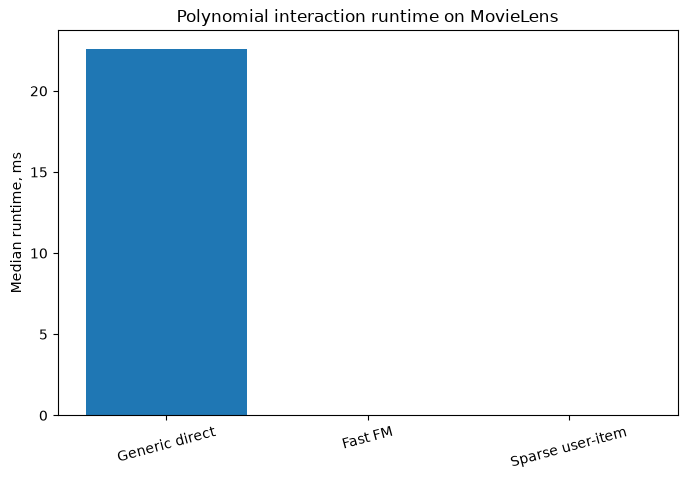

In [41]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    runtime_df["method"],
    runtime_df["runtime_ms"],
)

plt.ylabel(
    "Median runtime, ms"
)

plt.title(
    "Polynomial interaction runtime on MovieLens"
)

plt.xticks(
    rotation=15
)

plt.show()

In [42]:
n_users = data.n_users
n_items = data.n_items

n_features = (
    n_users
    + n_items
)

all_polynomial_pairs = (
    n_features
    * (n_features - 1)
    // 2
)

possible_user_item_pairs = (
    n_users
    * n_items
)

factorized_parameters = (
    n_features
    * n_factors
)

print(
    "All generic polynomial pairs:",
    all_polynomial_pairs,
)

print(
    "Possible user-item pairs:",
    possible_user_item_pairs,
)

print(
    "Factorized interaction parameters:",
    factorized_parameters,
)

All generic polynomial pairs: 1078246
Possible user-item pairs: 186060
Factorized interaction parameters: 23504


In [44]:
generic_compression = (
    all_polynomial_pairs
    / factorized_parameters
)

user_item_compression = (
    possible_user_item_pairs
    / factorized_parameters
)

print(
    f"Generic polynomial / factorized: "
    f"{generic_compression:.2f}x"
)

print(
    f"User-item interactions / factorized: "
    f"{user_item_compression:.2f}x"
)

Generic polynomial / factorized: 45.88x
User-item interactions / factorized: 7.92x


In [45]:
parameter_df = pd.DataFrame({
    "representation": [
        "Generic second-order polynomial",
        "Explicit user-item interactions",
        "Factorized representation",
    ],
    "interaction_parameters": [
        all_polynomial_pairs,
        possible_user_item_pairs,
        factorized_parameters,
    ],
})

parameter_df

,representation,interaction_parameters
0,Generic second-order polynomial,1078246
1,Explicit user-item interactions,186060
2,Factorized representation,23504


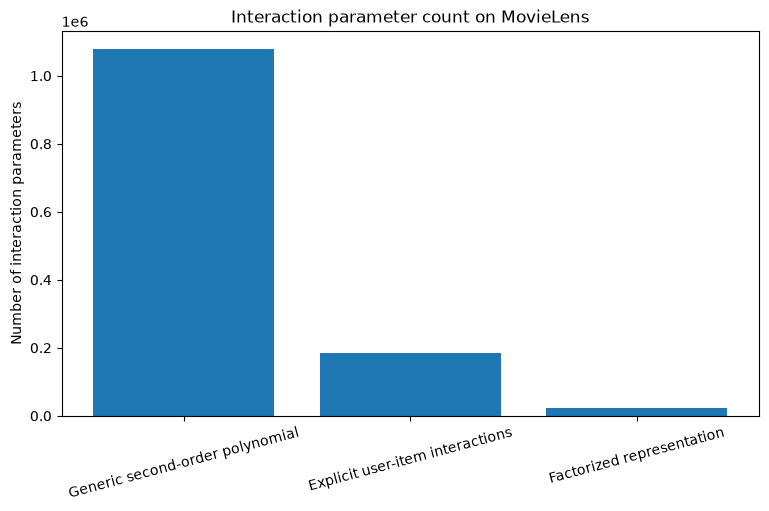

In [46]:
plt.figure(
    figsize=(9, 5)
)

plt.bar(
    parameter_df["representation"],
    parameter_df[
        "interaction_parameters"
    ],
)

plt.ylabel(
    "Number of interaction parameters"
)

plt.title(
    "Interaction parameter count on MovieLens"
)

plt.xticks(
    rotation=15
)

plt.show()